Проведите очистку данных на примере датасета с информацией о пассажирах корабля Титаник. На полученных данных обучите модель классификации с целевым признаком Survived (1 – пассажир выжил, 0 – погиб). Обучите модель на необработанных данных и посчитайте метрику качества. Проведите очистку данных. Обучите модель на данных после обработки, посчитайте метрику качества. Сравнить полученные результаты. Значение метрики должно улучшиться.

- Получите и загрузите данные.
- Удалите все пропущенные значения и категориальные переменные. Обучите модель. Выберете и посчитайте метрику качества.
- Снова загрузите полные данные.
- Удалите признаки, которые логически не нужны для построения модели. Обоснуйте.
- Проверьте данные на наличие пропущенных значений.
a) Посчитайте, какой процент данных будет потерян, если просто удалить пропуски.
b) Заполните пропуски: средним значением; константой; классом, указывающим на то, что значение было пропущено; случайным числом. Для разных признаков используйте подходящий метод. Можно не использовать все перечисленные методы.
- Категориальные переменные переведите в цифровые значения. Можно использовать pd.get_dummies, preprocessing.LabelEncoder. Старайтесь не использовать для этой задачи циклы.
- Проверьте данные на наличие выбросов.
a) Удалите выбросы, если считаете это целесообразным. Обоснуйте.
- *Постройте 1-2 графика на выбор. Визуализация должна быть основана на исследуемых данных и быть полезной (из графика можно сделать вывод об особенностях датасета/класса/признака)
*Попробуйте математически преобразовать признак Age.
- Обучите ту же модель, что в п. 2 на преобразованных данных. Посчитайте ту же, что в п. 2 метрику.
- Сформулируйте выводы по проделанной работе.
a) Кратко опишите какие преобразования были сделаны и почему.
b) Сравните метрики моделей из п. 2 и п. 10.
c) Напишите свое мнение о целесообразности работы с данными при построении моделей машинного обучения.
*Нужно ли аналогичным образом исследовать и дополнять действительно большие данные?

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
data = pd.read_csv('train.csv')
data.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### ⚛ 1 д/з

In [ ]:
tit = data.dropna()

In [ ]:
tit.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [ ]:
tit.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
x = tit[['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
y = tit['Survived']

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Pclass       183 non-null    int64  
 2   Age          183 non-null    float64
 3   SibSp        183 non-null    int64  
 4   Parch        183 non-null    int64  
 5   Fare         183 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 10.0 KB


In [ ]:
y.value_counts()

,count
Survived,
1,123
0,60


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=1)

In [ ]:
x_train.shape, x_test.shape

((146, 6), (37, 6))

In [ ]:
logreg = LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
logreg.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
#pred = logreg.predict_proba(x_test)

array([[0.19451837, 0.80548163],
       [0.79049135, 0.20950865],
       [0.42741276, 0.57258724],
       [0.48900953, 0.51099047],
       [0.7220471 , 0.2779529 ],
       [0.41087385, 0.58912615],
       [0.38750342, 0.61249658],
       [0.26628393, 0.73371607],
       [0.14238577, 0.85761423],
       [0.35432939, 0.64567061],
       [0.52642267, 0.47357733],
       [0.58665724, 0.41334276],
       [0.70043502, 0.29956498],
       [0.68564336, 0.31435664],
       [0.54588074, 0.45411926],
       [0.84450865, 0.15549135],
       [0.46376996, 0.53623004],
       [0.66701557, 0.33298443],
       [0.74146056, 0.25853944],
       [0.28648761, 0.71351239],
       [0.60335361, 0.39664639],
       [0.47955489, 0.52044511],
       [0.31525372, 0.68474628],
       [0.52967648, 0.47032352],
       [0.40580664, 0.59419336],
       [0.15607555, 0.84392445],
       [0.68881833, 0.31118167],
       [0.22342076, 0.77657924],
       [0.76226381, 0.23773619],
       [0.44805512, 0.55194488],
       [0.

In [ ]:
prediction = logreg.predict(x_test)

In [ ]:
logreg.score(x_train, y_train)

0.6575342465753424

In [ ]:
logreg_acc = round(logreg.score(x_test, y_test),2)

In [ ]:
logreg_f1 = round(f1_score(y_test, prediction),2)

In [ ]:
logreg_acc, logreg_f1

(0.54, 0.6)

In [ ]:
data.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


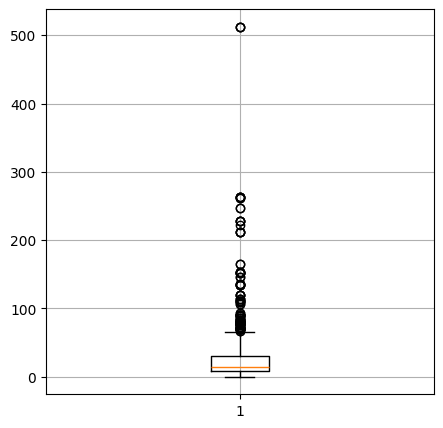

In [ ]:
plt.figure(figsize=(5,5))
plt.boxplot(data.Fare)
plt.grid()
plt.show()

<Axes: >

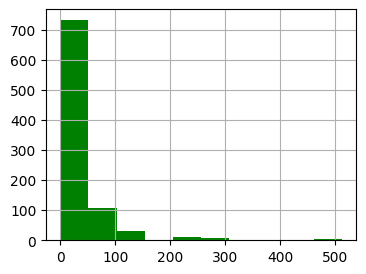

In [ ]:
plt.figure(figsize=(4,3))
data.Fare.hist(color='g')

In [ ]:
data = data[data.Fare < 80]

In [ ]:
df =  data[['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare']]

In [ ]:
y = data['Survived']
y.value_counts()

,count
Survived,
0,532
1,283


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 815 entries, 0 to 890
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  815 non-null    int64  
 1   Sex     815 non-null    object 
 2   Age     645 non-null    float64
 3   SibSp   815 non-null    int64  
 4   Parch   815 non-null    int64  
 5   Fare    815 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 44.6+ KB


In [ ]:
df.isna().sum()/len(df)*100

,0
Pclass,0.000000
Sex,0.000000
Age,20.858896
SibSp,0.000000
Parch,0.000000
Fare,0.000000


In [ ]:
lab = LabelEncoder().fit(df['Sex'])

In [ ]:
df['Sex'] = lab.transform(df['Sex'])

<ipython-input-57-de21949d3bb9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = lab.transform(df['Sex'])


In [ ]:
#df = pd.get_dummies(df) # если с категориальными признаками

In [ ]:
df.head(3)

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.0,1,0,7.2500
1,1,0,38.0,1,0,71.2833
2,3,0,26.0,0,0,7.9250


In [ ]:
df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('mean'))

<ipython-input-59-213f8b6ce7e0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('mean'))


In [ ]:
df.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0


In [ ]:
df.describe()

,Pclass,Sex,Age,SibSp,Parch,Fare
count,815.000000,815.000000,815.000000,815.000000,815.000000,815.000000
mean,2.430675,0.676074,29.001193,0.510429,0.353374,20.603333
std,0.767773,0.468260,13.183054,1.129056,0.790164,18.061385
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,22.000000,0.000000,0.000000,7.895800
50%,3.000000,1.000000,25.140620,0.000000,0.000000,13.000000
75%,3.000000,1.000000,36.000000,1.000000,0.000000,26.550000
max,3.000000,1.000000,80.000000,8.000000,6.000000,79.650000


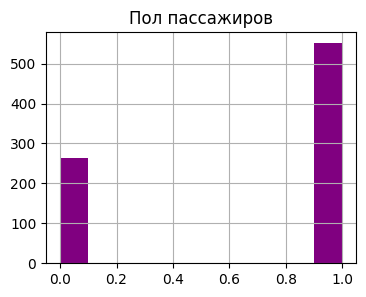

In [ ]:
plt.figure(figsize=(4,3))
plt.hist(df['Sex'], color='purple')
plt.title('Пол пассажиров')
plt.grid()
plt.show()

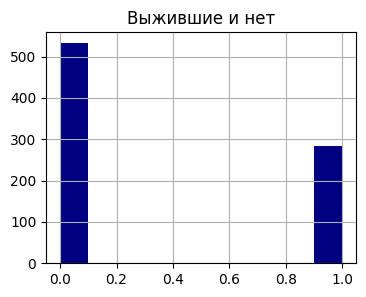

In [ ]:
plt.figure(figsize=(4,3))
plt.hist(y, color='navy')
plt.title('Выжившие и нет')
plt.grid()
plt.show()

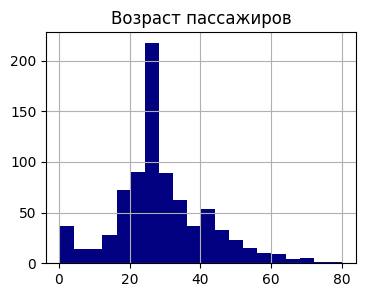

In [ ]:
plt.figure(figsize=(4,3))
plt.hist(df['Age'], color='navy', bins=20)
plt.title('Возраст пассажиров')
plt.grid()
plt.show()

In [ ]:
x_tr, x_ts, y_tr, y_ts = train_test_split(df, y, test_size=0.25, random_state=7)

In [ ]:
x_tr.shape, x_ts.shape

((611, 6), (204, 6))

In [ ]:
lreg = LogisticRegression(max_iter=1000, class_weight='balanced')
lreg.fit(x_tr, y_tr)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
preds = lreg.predict(x_ts)
lreg_f1 = round(f1_score(y_ts, preds),2)

In [ ]:
lreg.score(x_tr, y_tr)

0.7823240589198036

In [ ]:
lreg_acc = round(lreg.score(x_ts, y_ts),2)

In [ ]:
lreg_f1, lreg_acc

(0.72, 0.81)

In [ ]:
result = pd.DataFrame({'1 тест Accuracy': [logreg_acc],
                       '1 тест F1': [logreg_f1],
                       '2 тест Accuracy': [lreg_acc],
                       '2 тест F1': [lreg_f1]})
result.set_index(['1 тест Accuracy', '1 тест F1', '2 тест Accuracy', '2 тест F1'], inplace=True)

In [ ]:
result.T

1 тест Accuracy,0.54
1 тест F1,0.6
2 тест Accuracy,0.81
2 тест F1,0.72


### ⚛ 2 д/з

In [ ]:
data.info() # с столбцом Cabin совсем плохо, отсутствует более 50% данных, удаляю весь столбец
# у Age есть пропуски

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
data.drop(['Cabin'], axis=1).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [ ]:
data.dropna().info() # убираю пропуски

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  183 non-null    int64  
 1   Survived     183 non-null    int64  
 2   Pclass       183 non-null    int64  
 3   Name         183 non-null    object 
 4   Sex          183 non-null    object 
 5   Age          183 non-null    float64
 6   SibSp        183 non-null    int64  
 7   Parch        183 non-null    int64  
 8   Ticket       183 non-null    object 
 9   Fare         183 non-null    float64
 10  Cabin        183 non-null    object 
 11  Embarked     183 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.6+ KB


In [ ]:
data['Age'] = data['Age'].fillna(0) # заполняю nan на 0

In [ ]:
x = pd.get_dummies(data.loc[:, ['Pclass', 'Sex', 'Age', 'SibSp', 'Fare']])
y = data['Survived']

In [ ]:
model = LogisticRegression().fit(x, y)

In [ ]:
y_pred = model.predict(x)

In [ ]:
accuracy_score(y, y_pred)

0.7890011223344556

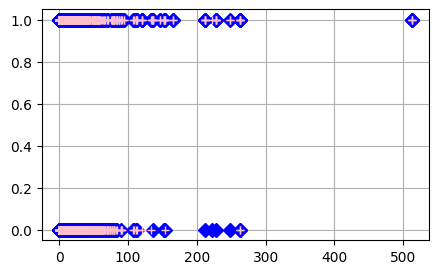

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(x, y, 'D', color='blue', markersize=7)
plt.plot(x, y_pred, '+', color='pink')
plt.grid()
plt.show()

In [ ]:
titanic = pd.read_csv('train.csv')
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
""" Надо удалять весь столбец номер Кабины, так как отсутствует около 80% данных + у нас есть класс кабины,
который может влиять на выживаемость: в каютах 1 класса на верхних палубах вероятнее выживаемость выше + номер билета
Ticket тоже удаляю, мне кажется, он не влияет также.
Думаю, что удалю Embarked, т.к. на выживаемость очень маловероятно влияло место, где сели пассажиры на корабль.
Можно удалить Имена, мне кажется, это прям не нужно. И id пассажира можно убрать, не влияет на целевую переменную точно."""

In [ ]:
titanic = titanic.drop(['Cabin','Embarked', 'Ticket', 'PassengerId', 'Name'], axis=1)

In [ ]:
titanic.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833


In [ ]:
(titanic.isna().mean()*100).round(2) # мы потеряем около 20% данных по возрасту пассажиров

,0
Survived,0.00
Pclass,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Fare,0.00


In [ ]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())

In [ ]:
titanic.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250


In [ ]:
(titanic.isna().mean()*100).round(2)

,0
Survived,0.0
Pclass,0.0
Sex,0.0
Age,0.0
SibSp,0.0
Parch,0.0
Fare,0.0


In [ ]:
# для заполнения константой можно также применить fillna
# titanic['Age'] = titanic['Age'].fillna(35)

In [ ]:
# считает возраст по медиане в каждой группе: мужчины и женщины и подставляем медиану в ячейки с пропусками
# data['Age'] = data['Age'].fillna(data.groupby('Sex')['Age'].transform('median'))

In [ ]:
l = LabelEncoder().fit(titanic['Sex'])

In [ ]:
titanic['Sex'] = l.transform(titanic['Sex'] )

In [ ]:
titanic.sample(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
660,1,1,1,50.000000,2,0,133.6500
502,0,3,0,29.699118,0,0,7.6292
384,0,3,1,29.699118,0,0,7.8958


In [ ]:
#titanic = pd.get_dummies(titanic.loc[:, ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']])

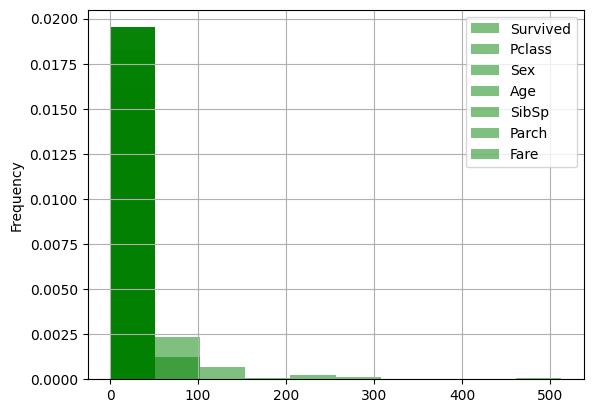

In [ ]:
#plt.figure(figsize=(4,3))
titanic.plot(kind='hist', density=3, alpha=.5, color='green') # от 100 есть выбросы
plt.grid()
plt.show()

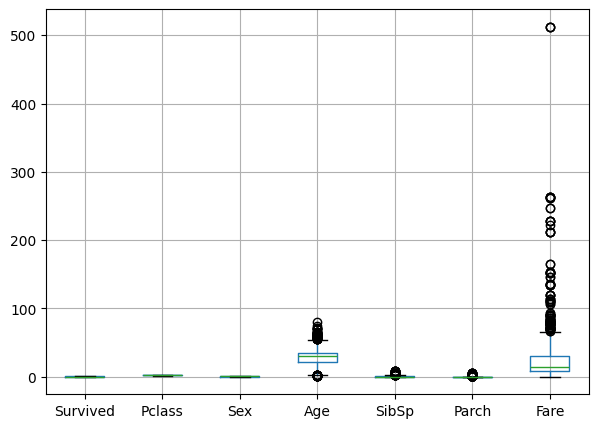

In [ ]:
plt.figure(figsize=(7, 5))
titanic.boxplot()
plt.show()

In [ ]:
titanic['Fare'].max()

512.3292

In [ ]:
#titanic['Fare'] = titanic['Fare'].replace(titanic['Fare'].max(), np.nan)

In [ ]:
#titanic['Fare'].max()

512.3292

In [ ]:
#titanic['Fare'] = titanic['Fare'].fillna(0)

In [ ]:
#(titanic.isna().mean()*100).round(2)

,0
Survived,0.0
Pclass,0.0
Sex,0.0
Age,0.0
SibSp,0.0
Parch,0.0
Fare,0.0


In [ ]:
"""
Я не совсем поняла, как могу код выше применить. То есть понимаю, что за границами lower и upper считаем выбросами,
но как их удалить... не поняла. Подскажите, пожалуйста, как удалить.
Но так как явный выброс был всего 1, то я его просто заменила на 0.
Данных за пределом upper много, потому думаю, что это не выбросы, а данные с ненормальным распределением и, возможно,
что данных у нас маловато.
"""

'\nЯ не совсем поняла, как могу код выше применить. То есть понимаю, что за границами lower и upper считаем выбросами, но как их удалить... не поняла. Подскажите, пожалуйста, как удалить.\nНо так как явный выброс был всего 1, то я его просто заменила на 0.\nДанных за пределом upper много, потому думаю, что это не выбросы, а данные с ненормальным распределением и, возможно, что данных у нас маловато.\n'

In [ ]:
# убираем выбросы с помощью квантилей

Q1 = titanic['Fare'].quantile(.25)
Q3 = titanic['Fare'].quantile(.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
titanic = titanic[titanic.Fare.between(lower, upper, inclusive='right')]

In [ ]:
Q1, Q3, IQR, lower, upper

(7.9104, 31.0, 23.0896, -26.724, 65.6344)

In [ ]:
titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.000000,1,0,7.2500
2,1,3,0,26.000000,0,0,7.9250
3,1,1,0,35.000000,1,0,53.1000
4,0,3,1,35.000000,0,0,8.0500
5,0,3,1,29.699118,0,0,8.4583
...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000
887,1,1,0,19.000000,0,0,30.0000
888,0,3,0,29.699118,1,2,23.4500
889,1,1,1,26.000000,0,0,30.0000


In [ ]:
titanic['Fare'].min(), titanic['Fare'].max()

(0.0, 65.0)

<Axes: >

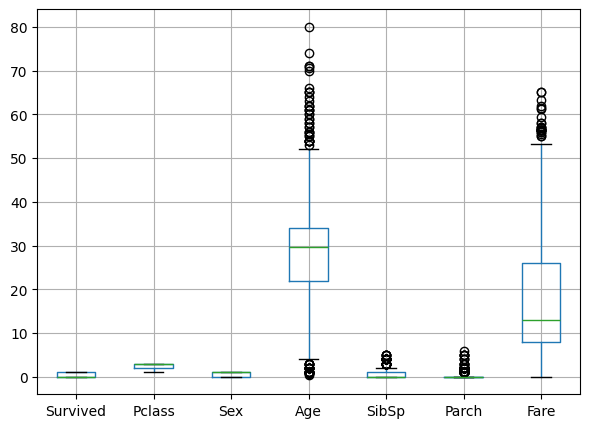

In [ ]:
plt.figure(figsize=(7, 5))
titanic.boxplot()
# видим, что много выбросов в Age и Fare, мне кажется, это говорит о ненормальном распределении

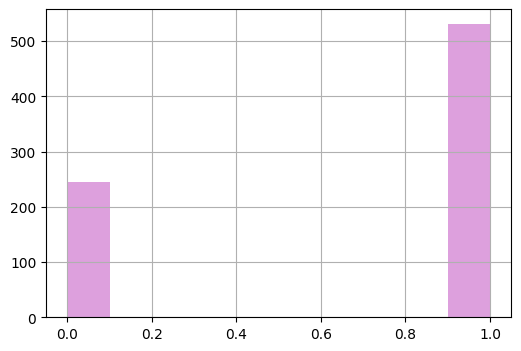

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(titanic['Sex'], color='plum')
plt.grid()
plt.show()

# график показывает явное различие между полами.Survived 0 - больше женщин, Survived 1 - больше мужчин

In [ ]:
x = titanic[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex']]
y = titanic['Survived']

In [ ]:
model2 = LogisticRegression(max_iter=1000).fit(x, y)

In [ ]:
y_pred = model2.predict(x)

In [ ]:
accuracy_score(y, y_pred)

0.7948387096774193

In [ ]:
titanic['New_age'] = np.log(titanic.Age)

<ipython-input-141-3984a0116a0f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic['New_age'] = np.log(titanic.Age)


In [ ]:
titanic.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,New_age
0,0,3,1,22.0,1,0,7.250,3.091042
2,1,3,0,26.0,0,0,7.925,3.258097


In [ ]:
x1 = titanic[['Pclass', 'SibSp', 'Parch', 'Fare', 'Sex', 'New_age']]
y1 = titanic['Survived']

In [ ]:
model3 = LogisticRegression(max_iter=1000).fit(x1, y1)

In [ ]:
y_pred2 = model3.predict(x1)

In [ ]:
accuracy_score(y1, y_pred2)

0.8051612903225807

In [ ]:
model3.score(x1, y1)

0.8051612903225807

In [ ]:
# После логарифмирования признака Age результат метрики улучшился